# Batched eigenvalues of complex non-Hermitian 3x3 matrices: CPU vs GPU

This notebook benchmarks the batched computation of the three eigenvalues of independent complex non-Hermitian $3\times 3$ matrices.

The GPU solver uses the closed-form cubic-root construction inspired by V. I. Lebedev, *On formulae for roots of cubic equation*, Sov. J. Numer. Anal. Math. Modelling, 6(4), 315-324, 1991. For the characteristic polynomial

$$
\lambda^3+b\lambda^2+c\lambda+d=0,
$$

it forms

$$
\tau=b^2-3c,\qquad q=b(9c-2b^2)-27d,\qquad
A=\frac{q}{2\tau\sqrt{\tau}},
$$

and evaluates the roots through Lebedev's Chebyshev representation. A separate branch is used when $\tau\approx 0$.

Three timings are reported:

1. **CPU / NumPy**: `np.linalg.eigvals`, used as the reference eigensolver;
2. **CPU / Lebedev**: a vectorized CPU implementation of the same cubic formula used by the GPU;
3. **GPU / Lebedev**: one CUDA thread per matrix.

For the GPU, both **kernel-only** time and **end-to-end** time (host-to-device copy + kernel + device-to-host copy) are measured. The same random matrices are used on CPU and GPU.

## 1. Setup

On Google Colab, select a GPU runtime before running the notebook. If PyCUDA is not available, uncomment the installation cell below.

In [ ]:
# Uncomment only if PyCUDA is missing in your environment.
# %pip -q install pycuda

In [ ]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 11.8 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp313-cp313-linux_x86_64.whl size=5281392 sha256=9825176d444e96ba8e8157d7d582c9fd0649fe21540a17ea33fb64996d7e38c9
  Stored in directory: /root/.cache/pip/wheels/ce/26/46/c519675fcb0e5e17bab8e85b6676528c40d12d794182340e85
Successfully built pycuda


In [ ]:
import itertools
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule

np.set_printoptions(precision=6, suppress=True)

print("NumPy version:", np.__version__)
dev = cuda.Device(0)
print("GPU:", dev.name())
print("Compute capability:", dev.compute_capability())

NumPy version: 2.1.3
GPU: Tesla T4
Compute capability: (7, 5)


## 2. Parameters

`BATCH_SIZES` is the number of independent $3\times 3$ matrices processed in one batch. All matrices use `complex64`, matching the single-precision CUDA kernel.

In [ ]:
SEED = 12345
BATCH_SIZES = [1_000, 3_000, 10_000, 30_000, 100_000, 300_000]
N_REPEAT_CPU = 3
N_REPEAT_GPU = 10
BLOCK_SIZE = 256

# Threshold for the tau ~= 0 special case in the closed-form solver.
TAU_EPS = 2e-6

## 3. Random non-Hermitian matrices

The matrices are fully complex and no Hermitian symmetry is imposed. The batch has shape `(N, 3, 3)` and is C-contiguous, so each CUDA thread reads the nine entries of one matrix.

In [ ]:
def generate_random_matrices(n, rng):
    real = rng.standard_normal((n, 3, 3), dtype=np.float32)
    imag = rng.standard_normal((n, 3, 3), dtype=np.float32)
    return np.ascontiguousarray(real + 1j * imag, dtype=np.complex64)

## 4. CPU implementation of the Lebedev cubic formula

The branch $A+\sqrt{A^2-1}$ must be selected consistently. Since the two candidates are reciprocal, the implementation chooses the one with modulus at least as large as the other; this gives the $R\ge 1$ branch used in the paper.

When $	au$ is numerically close to zero, the general expression divides by $	au\sqrt{	au}$ and becomes ill-conditioned. In that case the shifted cubic reduces to $y^3=q/27$, which is solved directly.

In [ ]:
def characteristic_coefficients_3x3(M):
    """Return b,c,d for det(lambda I - M) = lambda^3 + b lambda^2 + c lambda + d."""
    a11, a12, a13 = M[:, 0, 0], M[:, 0, 1], M[:, 0, 2]
    a21, a22, a23 = M[:, 1, 0], M[:, 1, 1], M[:, 1, 2]
    a31, a32, a33 = M[:, 2, 0], M[:, 2, 1], M[:, 2, 2]

    b = -(a11 + a22 + a33)
    c = (a11*a22 + a11*a33 + a22*a33) - (a12*a21 + a13*a31 + a23*a32)
    detM = (a11*a22*a33 + a12*a23*a31 + a13*a21*a32
            - a13*a22*a31 - a12*a21*a33 - a11*a23*a32)
    d = -detM
    return b, c, d


def eigvals_lebedev_cpu(M, tau_eps=TAU_EPS):
    """Vectorized Lebedev-style eigensolver for a batch of complex 3x3 matrices."""
    b, c, d = characteristic_coefficients_3x3(M)
    tau = b*b - np.complex64(3.0)*c
    q = b*(np.complex64(9.0)*c - np.complex64(2.0)*b*b) - np.complex64(27.0)*d

    roots = np.empty((M.shape[0], 3), dtype=np.complex64)

    # Scale-aware test for tau ~= 0.
    scale = np.maximum(np.maximum(np.abs(b)**2, np.float32(3.0)*np.abs(c)), np.float32(1.0))
    regular = np.abs(tau) > np.float32(tau_eps)*scale

    if np.any(regular):
        tr = tau[regular]
        qr = q[regular]
        br = b[regular]

        sqrt_tau = np.sqrt(tr)
        beta = np.complex64(2.0)*sqrt_tau/np.complex64(3.0)
        gamma = -br/np.complex64(3.0)
        Aval = qr/(np.complex64(2.0)*tr*sqrt_tau)

        disc = np.sqrt(Aval*Aval - np.complex64(1.0))
        z1 = Aval + disc
        z2 = Aval - disc
        z = np.where(np.abs(z1) >= np.abs(z2), z1, z2)

        R = np.maximum(np.abs(z).astype(np.float32), np.float32(1e-20))
        phi = np.angle(z).astype(np.float32)
        R13 = np.cbrt(R).astype(np.float32)
        Rp = R13 + np.float32(1.0)/R13
        Rm = R13 - np.float32(1.0)/R13

        for k in range(3):
            theta = (phi + np.float32(2.0*np.pi*k))/np.float32(3.0)
            y = np.complex64(0.5)*(Rp*np.cos(theta) + 1j*Rm*np.sin(theta))
            roots[regular, k] = beta*y + gamma

    if np.any(~regular):
        # For tau = 0, after x = y - b/3: y^3 = q/27.
        q3 = q[~regular]/np.complex64(27.0)
        rho = np.cbrt(np.abs(q3)).astype(np.float32)
        theta = np.angle(q3).astype(np.float32)/np.float32(3.0)
        principal = rho*np.exp(1j*theta).astype(np.complex64)
        gamma = -b[~regular]/np.complex64(3.0)
        omega = np.complex64(-0.5 + 0.8660254037844386j)
        roots[~regular, 0] = principal + gamma
        roots[~regular, 1] = principal*omega + gamma
        roots[~regular, 2] = principal*omega*omega + gamma

    return roots

## 5. CUDA kernel

The kernel follows the same equations as the CPU implementation. Each thread computes the characteristic-polynomial coefficients and all three roots for one matrix. This avoids calling a general-purpose iterative eigensolver for each tiny matrix.

In [ ]:
cuda_source = r"""
#include <pycuda-complex.hpp>
typedef pycuda::complex<float> cmplx;

#define PI_F 3.14159265358979323846f
#define SQRT3_OVER_2_F 0.86602540378443864676f

__global__ void eig3_lebedev(
    const cmplx *M,
    cmplx *E,
    const int N,
    const float tau_eps)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;

    const cmplx *A = M + 9*i;
    cmplx a11=A[0], a12=A[1], a13=A[2];
    cmplx a21=A[3], a22=A[4], a23=A[5];
    cmplx a31=A[6], a32=A[7], a33=A[8];

    // det(lambda I - A) = lambda^3 + b lambda^2 + c lambda + d
    cmplx b = -(a11 + a22 + a33);
    cmplx c = (a11*a22 + a11*a33 + a22*a33)
              - (a12*a21 + a13*a31 + a23*a32);
    cmplx detA = a11*a22*a33 + a12*a23*a31 + a13*a21*a32
               - a13*a22*a31 - a12*a21*a33 - a11*a23*a32;
    cmplx d = -detA;

    cmplx tau = b*b - cmplx(3.0f,0.0f)*c;
    cmplx q = b*(cmplx(9.0f,0.0f)*c - cmplx(2.0f,0.0f)*b*b)
              - cmplx(27.0f,0.0f)*d;

    float scale = fmaxf(fmaxf(abs(b)*abs(b), 3.0f*abs(c)), 1.0f);
    cmplx gamma = -b/cmplx(3.0f,0.0f);

    if (abs(tau) <= tau_eps*scale) {
        // tau = 0 => shifted equation y^3 = q/27.
        cmplx q3 = q/cmplx(27.0f,0.0f);
        float rho = cbrtf(abs(q3));
        float theta = atan2f(q3.imag(), q3.real())/3.0f;
        cmplx principal = cmplx(rho*cosf(theta), rho*sinf(theta));
        cmplx omega = cmplx(-0.5f, SQRT3_OVER_2_F);
        E[3*i+0] = principal + gamma;
        E[3*i+1] = principal*omega + gamma;
        E[3*i+2] = principal*omega*omega + gamma;
        return;
    }

    cmplx sqrt_tau = sqrt(tau);
    cmplx beta = cmplx(2.0f,0.0f)*sqrt_tau/cmplx(3.0f,0.0f);
    cmplx Aval = q/(cmplx(2.0f,0.0f)*tau*sqrt_tau);

    cmplx disc = sqrt(Aval*Aval - cmplx(1.0f,0.0f));
    cmplx z1 = Aval + disc;
    cmplx z2 = Aval - disc;
    cmplx z = (abs(z1) >= abs(z2)) ? z1 : z2;

    float R = fmaxf(abs(z), 1e-20f);
    float phi = atan2f(z.imag(), z.real());
    float R13 = cbrtf(R);
    float Rp = R13 + 1.0f/R13;
    float Rm = R13 - 1.0f/R13;

    #pragma unroll
    for (int k=0; k<3; ++k) {
        float theta = (phi + 2.0f*PI_F*k)/3.0f;
        cmplx y = cmplx(0.5f*Rp*cosf(theta), 0.5f*Rm*sinf(theta));
        E[3*i+k] = beta*y + gamma;
    }
}
"""

mod = SourceModule(cuda_source, options=["-O3"])
eig3_gpu_kernel = mod.get_function("eig3_lebedev")
print("CUDA kernel compiled successfully.")

CUDA kernel compiled successfully.


## 6. GPU helper and root matching

Eigenvalue ordering is arbitrary. For accuracy checks, all six permutations of the three roots are tested and the best matching is used. This is safer than sorting by magnitude, especially near repeated or clustered eigenvalues.

In [ ]:
PERMS = np.array(list(itertools.permutations(range(3))), dtype=np.int32)


def best_root_errors(reference, test):
    """Per-matrix best max absolute and relative errors over all 3! root permutations."""
    ref = np.asarray(reference)
    tst = np.asarray(test)
    best_abs = np.full(ref.shape[0], np.inf, dtype=np.float64)
    best_rel = np.full(ref.shape[0], np.inf, dtype=np.float64)

    ref_scale = np.maximum(np.max(np.abs(ref), axis=1), 1e-20)
    for p in PERMS:
        e = np.max(np.abs(tst[:, p] - ref), axis=1)
        best_abs = np.minimum(best_abs, e)
        best_rel = np.minimum(best_rel, e/ref_scale)
    return best_abs, best_rel


def gpu_run_once(M, block_size=BLOCK_SIZE, tau_eps=TAU_EPS):
    """Return GPU eigenvalues plus kernel-only and end-to-end times in milliseconds."""
    M = np.ascontiguousarray(M, dtype=np.complex64)
    N = M.shape[0]
    out = np.empty((N, 3), dtype=np.complex64)

    d_M = cuda.mem_alloc(M.nbytes)
    d_E = cuda.mem_alloc(out.nbytes)
    grid = ((N + block_size - 1)//block_size, 1, 1)
    block = (block_size, 1, 1)

    # Warm-up.
    cuda.memcpy_htod(d_M, M)
    eig3_gpu_kernel(d_M, d_E, np.int32(N), np.float32(tau_eps), block=block, grid=grid)
    cuda.Context.synchronize()

    # Kernel-only timing with CUDA events.
    start = cuda.Event(); stop = cuda.Event()
    start.record()
    eig3_gpu_kernel(d_M, d_E, np.int32(N), np.float32(tau_eps), block=block, grid=grid)
    stop.record(); stop.synchronize()
    kernel_ms = start.time_till(stop)

    # End-to-end timing: H2D + kernel + D2H. Allocation is intentionally excluded.
    t0 = time.perf_counter()
    cuda.memcpy_htod(d_M, M)
    eig3_gpu_kernel(d_M, d_E, np.int32(N), np.float32(tau_eps), block=block, grid=grid)
    cuda.memcpy_dtoh(out, d_E)
    cuda.Context.synchronize()
    e2e_ms = 1e3*(time.perf_counter() - t0)

    return out, kernel_ms, e2e_ms

## 7. Correctness check

NumPy is used as the reference. The custom CPU and GPU implementations should agree up to the accuracy expected from `complex64`. The residual of the characteristic polynomial is also evaluated for the GPU roots.

In [ ]:
def polynomial_residual(M, roots):
    b, c, d = characteristic_coefficients_3x3(M)
    lam = roots
    res = lam**3 + b[:,None]*lam**2 + c[:,None]*lam + d[:,None]
    scale = (np.abs(lam)**3 + np.abs(b[:,None])*np.abs(lam)**2
             + np.abs(c[:,None])*np.abs(lam) + np.abs(d[:,None]) + 1e-20)
    return np.abs(res)/scale

rng = np.random.default_rng(SEED)
M_test = generate_random_matrices(20_000, rng)

ref = np.linalg.eigvals(M_test)
cpu_closed = eigvals_lebedev_cpu(M_test)
gpu_closed, kernel_ms, e2e_ms = gpu_run_once(M_test)

cpu_abs, cpu_rel = best_root_errors(ref, cpu_closed)
gpu_abs, gpu_rel = best_root_errors(ref, gpu_closed)
gpu_res = polynomial_residual(M_test, gpu_closed)

print(f"CPU Lebedev vs NumPy: median rel. error = {np.median(cpu_rel):.3e}, "
      f"99th percentile = {np.quantile(cpu_rel, 0.99):.3e}, max = {cpu_rel.max():.3e}")
print(f"GPU Lebedev vs NumPy: median rel. error = {np.median(gpu_rel):.3e}, "
      f"99th percentile = {np.quantile(gpu_rel, 0.99):.3e}, max = {gpu_rel.max():.3e}")
print(f"GPU normalized polynomial residual: median = {np.median(gpu_res):.3e}, "
      f"99th percentile = {np.quantile(gpu_res, 0.99):.3e}, max = {gpu_res.max():.3e}")
print(f"Example GPU timing for 20,000 matrices: kernel={kernel_ms:.3f} ms, end-to-end={e2e_ms:.3f} ms")

CPU Lebedev vs NumPy: median rel. error = 1.444e-07, 99th percentile = 4.312e-07, max = 1.241e-06
GPU Lebedev vs NumPy: median rel. error = 1.402e-07, 99th percentile = 4.177e-07, max = 1.158e-06
GPU normalized polynomial residual: median = 6.522e-08, 99th percentile = 6.939e-07, max = 2.317e-05
Example GPU timing for 20,000 matrices: kernel=0.083 ms, end-to-end=0.601 ms


## 8. Benchmark

The batch is generated once on the CPU and the identical matrices are used by all solvers. GPU memory allocation and CUDA compilation are excluded from the measured execution times. This makes the comparison reproducible while keeping separate the two practically relevant GPU cases:

- **kernel-only**: appropriate if preceding and subsequent processing stages already keep the data on the GPU;
- **end-to-end**: appropriate if each batch starts and ends in host memory.

In [ ]:
def median_time_ms(func, n_repeat):
    times = []
    result = None
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        result = func()
        times.append(1e3*(time.perf_counter() - t0))
    return result, float(np.median(times))


def benchmark_batch(N, seed=SEED):
    rng = np.random.default_rng(seed + N)
    M = generate_random_matrices(N, rng)

    # Warm-up CPU paths.
    _ = np.linalg.eigvals(M[:min(N, 1024)])
    _ = eigvals_lebedev_cpu(M[:min(N, 1024)])

    ref, t_numpy = median_time_ms(lambda: np.linalg.eigvals(M), N_REPEAT_CPU)
    cpu_closed, t_cpu_closed = median_time_ms(lambda: eigvals_lebedev_cpu(M), N_REPEAT_CPU)

    # Prepare GPU buffers once. Allocation excluded from timing.
    out = np.empty((N, 3), dtype=np.complex64)
    d_M = cuda.mem_alloc(M.nbytes)
    d_E = cuda.mem_alloc(out.nbytes)
    block = (BLOCK_SIZE, 1, 1)
    grid = ((N + BLOCK_SIZE - 1)//BLOCK_SIZE, 1, 1)

    cuda.memcpy_htod(d_M, M)
    eig3_gpu_kernel(d_M, d_E, np.int32(N), np.float32(TAU_EPS), block=block, grid=grid)
    cuda.Context.synchronize()

    # Kernel-only: median over repeated CUDA-event measurements.
    k_times = []
    for _ in range(N_REPEAT_GPU):
        start = cuda.Event(); stop = cuda.Event()
        start.record()
        eig3_gpu_kernel(d_M, d_E, np.int32(N), np.float32(TAU_EPS), block=block, grid=grid)
        stop.record(); stop.synchronize()
        k_times.append(start.time_till(stop))
    t_gpu_kernel = float(np.median(k_times))

    # End-to-end: H2D + kernel + D2H; allocation excluded.
    e2e_times = []
    for _ in range(max(3, N_REPEAT_GPU//2)):
        t0 = time.perf_counter()
        cuda.memcpy_htod(d_M, M)
        eig3_gpu_kernel(d_M, d_E, np.int32(N), np.float32(TAU_EPS), block=block, grid=grid)
        cuda.memcpy_dtoh(out, d_E)
        cuda.Context.synchronize()
        e2e_times.append(1e3*(time.perf_counter() - t0))
    t_gpu_e2e = float(np.median(e2e_times))

    # Retrieve a fresh GPU result for the accuracy statistics.
    eig3_gpu_kernel(d_M, d_E, np.int32(N), np.float32(TAU_EPS), block=block, grid=grid)
    cuda.memcpy_dtoh(out, d_E)
    cuda.Context.synchronize()

    _, rel_cpu = best_root_errors(ref, cpu_closed)
    _, rel_gpu = best_root_errors(ref, out)

    return {
        "N": N,
        "CPU NumPy [ms]": t_numpy,
        "CPU Lebedev [ms]": t_cpu_closed,
        "GPU kernel [ms]": t_gpu_kernel,
        "GPU end-to-end [ms]": t_gpu_e2e,
        "Speedup kernel / NumPy": t_numpy/t_gpu_kernel,
        "Speedup e2e / NumPy": t_numpy/t_gpu_e2e,
        "CPU Lebedev rel.err p99": float(np.quantile(rel_cpu, 0.99)),
        "GPU Lebedev rel.err p99": float(np.quantile(rel_gpu, 0.99)),
        "GPU Lebedev rel.err max": float(np.max(rel_gpu)),
    }


rows = []
for N in BATCH_SIZES:
    print(f"Benchmarking N={N:,} ...")
    rows.append(benchmark_batch(N))

results = pd.DataFrame(rows)
results

Benchmarking N=1,000 ...
Benchmarking N=3,000 ...
Benchmarking N=10,000 ...
Benchmarking N=30,000 ...
Benchmarking N=100,000 ...
Benchmarking N=300,000 ...


,N,CPU NumPy [ms],CPU Lebedev [ms],GPU kernel [ms],GPU end-to-end [ms],Speedup kernel / NumPy,Speedup e2e / NumPy,CPU Lebedev rel.err p99,GPU Lebedev rel.err p99,GPU Lebedev rel.err max
0,1000,10.918611,0.789436,0.032768,0.075134,333.209565,145.321838,4.342981e-07,4.304896e-07,5.454348e-07
1,3000,34.903342,1.520868,0.029920,0.120379,1166.555562,289.945439,4.501296e-07,4.234935e-07,8.696290e-07
2,10000,115.943947,4.161773,0.035600,0.331307,3256.852523,349.959243,4.487344e-07,4.261467e-07,7.318649e-07
3,30000,342.737882,12.713939,0.045424,0.813795,7545.303943,421.159975,4.381950e-07,4.201591e-07,2.172865e-06
4,100000,622.440124,35.846175,0.078032,2.296261,7976.729277,271.066801,4.373801e-07,4.217653e-07,1.900680e-06
5,300000,3824.689094,143.677758,0.176416,6.975185,21679.945172,548.327979,4.402520e-07,4.217772e-07,2.219961e-06


## 9. Plots

The figures are displayed directly in the notebook and are not saved to disk.

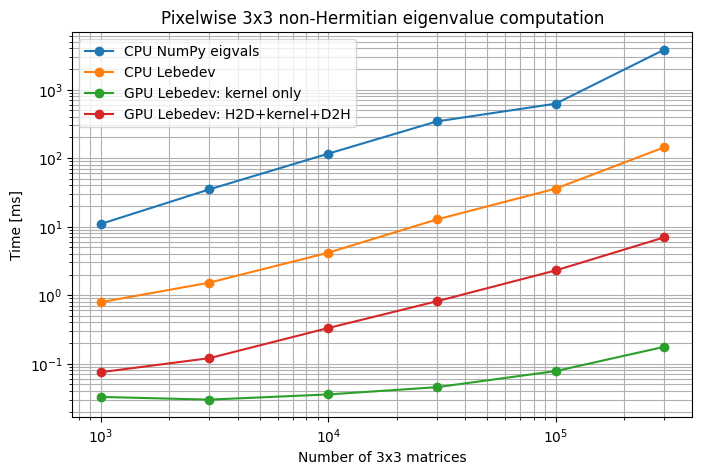

In [ ]:
plt.figure(figsize=(8, 5))
plt.loglog(results["N"], results["CPU NumPy [ms]"], "o-", label="CPU NumPy eigvals")
plt.loglog(results["N"], results["CPU Lebedev [ms]"], "o-", label="CPU Lebedev")
plt.loglog(results["N"], results["GPU kernel [ms]"], "o-", label="GPU Lebedev: kernel only")
plt.loglog(results["N"], results["GPU end-to-end [ms]"], "o-", label="GPU Lebedev: H2D+kernel+D2H")
plt.xlabel("Number of 3x3 matrices")
plt.ylabel("Time [ms]")
plt.title("Batched 3x3 non-Hermitian eigenvalue computation")
plt.grid(True, which="both")
plt.legend()
plt.show()

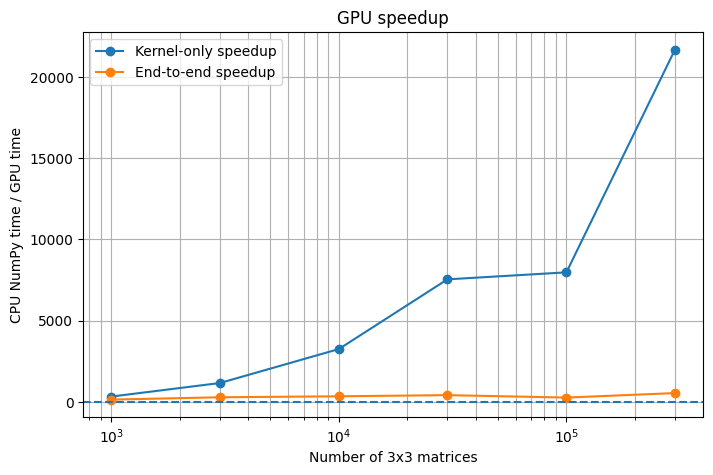

In [ ]:
plt.figure(figsize=(8, 5))
plt.semilogx(results["N"], results["Speedup kernel / NumPy"], "o-", label="Kernel-only speedup")
plt.semilogx(results["N"], results["Speedup e2e / NumPy"], "o-", label="End-to-end speedup")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Number of 3x3 matrices")
plt.ylabel("CPU NumPy time / GPU time")
plt.title("GPU speedup")
plt.grid(True, which="both")
plt.legend()
plt.show()

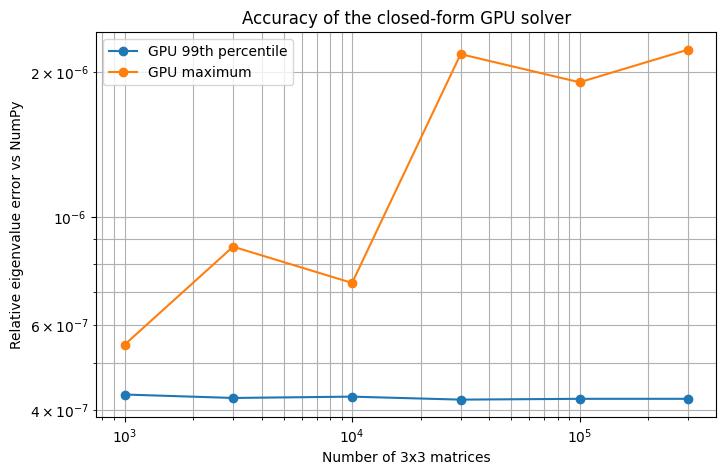

In [ ]:
plt.figure(figsize=(8, 5))
plt.loglog(results["N"], results["GPU Lebedev rel.err p99"], "o-", label="GPU 99th percentile")
plt.loglog(results["N"], results["GPU Lebedev rel.err max"], "o-", label="GPU maximum")
plt.xlabel("Number of 3x3 matrices")
plt.ylabel("Relative eigenvalue error vs NumPy")
plt.title("Accuracy of the closed-form GPU solver")
plt.grid(True, which="both")
plt.legend()
plt.show()

## 10. Interpretation of the benchmark

For a publication, do not report only a speedup on uniformly random matrices. The random benchmark is useful for raw computational scaling, but an application-oriented validation should additionally include matrices obtained from the target processing chain and difficult cases with clustered/repeated eigenvalues.

Recommended experiments:

- random generic complex non-Hermitian matrices (this notebook);
- matrices extracted from representative application data;
- controlled matrices with prescribed eigenvalue separation / condition number;
- cases with $|\tau|$ close to zero;
- `complex64` versus `complex128` reference accuracy;
- kernel-only and end-to-end timings separately;
- comparison against a library batched eigensolver, where available.

The closed-form cubic method is attractive on a GPU because the matrix size is fixed and tiny, and one matrix can be mapped to one thread. Its main scientific issue is not the algebraic existence of a formula, but **numerical robustness** for ill-conditioned or nearly defective non-Hermitian matrices. Therefore, accuracy/robustness experiments are as important as timing experiments.